<a href="https://colab.research.google.com/github/Narasimhan15/NammaFlow/blob/main/02_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NammaFlow — Exploratory Data Analysis

## Phase 2: Demand, Funnel, Operations & Driver Intelligence

### Project
**NammaFlow: Urban Mobility Demand & Supply Intelligence for Namma Yatri — Bengaluru**

### Objective

The purpose of Phase 2 is to explore the cleaned Namma Yatri operational datasets produced during Phase 1 and identify meaningful mobility patterns across time, vehicle categories, booking behaviour, wards, cancellations, conversion funnels, and driver supply.

The analysis will focus on answering questions such as:

- When is ride demand highest and lowest?
- How does demand change by hour and date?
- Which vehicle and trip categories generate the most bookings and completed rides?
- Where does the search-to-ride funnel lose the most users?
- What are the major causes and patterns of ride cancellations?
- Which Bengaluru wards experience high demand or weak conversion?
- Where do potential driver supply-demand mismatches exist?
- What operational insights can help improve ride fulfilment and driver allocation?

The findings from this phase will later support feature engineering, machine learning, supply-demand intelligence, and dashboard development.

In [1]:
!git clone https://github.com/Narasimhan15/NammaFlow.git

Cloning into 'NammaFlow'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 31 (delta 6), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 263.48 KiB | 2.66 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
%cd /content/NammaFlow

/content/NammaFlow


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [4]:
!ls -lh data/processed/

total 352K
-rw-r--r-- 1 root root  30K Sep 30 19:49 city_demand_bengaluru.csv
-rw-r--r-- 1 root root  50K Sep 30 19:49 city_operations_bengaluru.csv
-rw-r--r-- 1 root root  100 Sep 30 19:49 date_coverage.csv
-rw-r--r-- 1 root root  12K Sep 30 19:49 driver_supply_clean.csv
-rw-r--r-- 1 root root 249K Sep 30 19:49 ward_funnel_clean.csv


---

## 1. Environment Setup & Processed Data Loading

Phase 1 completed the structural validation, cleaning, and preparation of the raw Namma Yatri datasets.

Therefore, Phase 2 uses the processed datasets directly rather than repeating the raw-data cleaning workflow.

### Processed datasets

- `city_demand_bengaluru.csv` — city-level demand and search behaviour
- `city_operations_bengaluru.csv` — vehicle-level bookings, rides, cancellations and earnings
- `ward_funnel_clean.csv` — ward-level search and conversion funnel
- `driver_supply_clean.csv` — ward-level driver supply information
- `date_coverage.csv` — dataset date coverage information

This separation keeps the project modular and ensures that exploratory analysis is reproducible without duplicating Phase 1 preprocessing.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
city_demand = pd.read_csv("data/processed/city_demand_bengaluru.csv")
city_operations = pd.read_csv("data/processed/city_operations_bengaluru.csv")
ward_funnel = pd.read_csv("data/processed/ward_funnel_clean.csv")
driver_supply = pd.read_csv("data/processed/driver_supply_clean.csv")
date_coverage = pd.read_csv("data/processed/date_coverage.csv")

print("Processed datasets loaded successfully.")

Processed datasets loaded successfully.


In [7]:
print("city_demand shape     :", city_demand.shape)
print("city_operations shape :", city_operations.shape)
print("ward_funnel shape     :", ward_funnel.shape)
print("driver_supply shape   :", driver_supply.shape)
print("date_coverage shape   :", date_coverage.shape)

city_demand shape     : (306, 24)
city_operations shape : (505, 24)
ward_funnel shape     : (2928, 29)
driver_supply shape   : (486, 6)
date_coverage shape   : (3, 3)


---

## 2. Phase 2 : Data Integrity Validation

Before beginning exploratory analysis, the processed datasets are revalidated to ensure that the Phase 1 outputs were loaded correctly.

The validation checks:

- Dataset dimensions
- Missing values
- Duplicate rows
- Date coverage
- Data types

This step is not intended to repeat Phase 1 cleaning. It acts as a lightweight validation layer before calculating business KPIs and performing exploratory analysis.

In [8]:
datasets = {
    "City Demand": city_demand,
    "City Operations": city_operations,
    "Ward Funnel": ward_funnel,
    "Driver Supply": driver_supply
}

integrity_summary = []

for name, df in datasets.items():
    integrity_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Values": df.isnull().sum().sum()
    })

integrity_summary = pd.DataFrame(integrity_summary)

integrity_summary

,Dataset,Rows,Columns,Duplicate Rows,Missing Values
0,City Demand,306,24,0,306
1,City Operations,505,24,0,1091
2,Ward Funnel,2928,29,0,15533
3,Driver Supply,486,6,0,0


Missing values by columns

In [9]:
for name, df in datasets.items():

    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("No missing values.")
    else:
        display(
            pd.DataFrame({
                "Missing_Count": missing,
                "Missing_%": (missing / len(df) * 100).round(2)
            })
        )


City Demand


,Missing_Count,Missing_%
bkng_cancel_rate,306,100.0



City Operations


,Missing_Count,Missing_%
cnvr_rate,505,100.00
q_accept_rate,505,100.00
bkng_cancel_rate,81,16.04



Ward Funnel


,Missing_Count,Missing_%
q_to_bkng_rate,2617,89.38
q_accept_rate,2615,89.31
e_to_q_srch_rate,2614,89.28
srch_to_e_rate,2614,89.28
cnvr_rate,2614,89.28
bkng_cancel_rate,2459,83.98



Driver Supply
No missing values.


### Missing-Value Observation

Missing values are concentrated primarily in derived rate columns rather than the underlying activity-count columns.

These values are not automatically imputed or removed because a missing rate can occur when the metric is not applicable or when the denominator required to calculate the rate is zero.

The underlying numerator and denominator columns will therefore be validated before interpreting these rate fields.

In [10]:
date_coverage

,date,hours_available,day_status
0,2026-05-03,24,Complete
1,2026-05-09,24,Complete
2,2026-05-10,16,Partial


### Date-Coverage Observation

The city-level dataset contains three observed dates:

- **2026-05-03:** 24 hours — Complete
- **2026-05-09:** 24 hours — Complete
- **2026-05-10:** 16 hours — Partial

Because 2026-05-10 contains only 16 observed hours, its raw daily totals are not directly comparable with the two complete 24-hour dates.

Where date-level comparisons are required, the analysis will either:

1. compare equivalent observed hours across dates, or
2. use normalized metrics such as activity per observed hour.

This prevents the partial day from being incorrectly interpreted as lower demand or weaker operational performance.

In [11]:
print("CITY DEMAND")
print("-" * 50)

print("Total bookings:", city_demand["booking"].sum())
print("Total cancellations:", city_demand["cancel_ride"].sum())
print("Non-null booking cancellation rate:",
      city_demand["bkng_cancel_rate"].notna().sum())


print("\nCITY OPERATIONS")
print("-" * 50)

print("Total searches:", city_operations["srch_rqst"].sum())
print("Total quote searches:", city_operations["srch_fr_q"].sum())
print("Total bookings:", city_operations["booking"].sum())

print("Non-null conversion rate:",
      city_operations["cnvr_rate"].notna().sum())

print("Non-null quote acceptance rate:",
      city_operations["q_accept_rate"].notna().sum())

print("Non-null booking cancellation rate:",
      city_operations["bkng_cancel_rate"].notna().sum())

CITY DEMAND
--------------------------------------------------
Total bookings: 0
Total cancellations: 0
Non-null booking cancellation rate: 0

CITY OPERATIONS
--------------------------------------------------
Total searches: 0
Total quote searches: 0
Total bookings: 442586
Non-null conversion rate: 0
Non-null quote acceptance rate: 0
Non-null booking cancellation rate: 424


This code will tell us whether those rate columns are simply unavailable for those particular row types rather than representing genuinely missing operational records.

### Structural Missingness Validation

The city-level processed datasets represent separate analytical layers.

- `city_demand` contains demand/search activity and does not contain active booking or cancellation metrics.
- `city_operations` contains booking and downstream operational activity but does not contain active search or quote-search metrics.

Therefore, missing values in derived rate fields such as `cnvr_rate`, `q_accept_rate`, and `bkng_cancel_rate` are primarily structural rather than conventional missing-data problems.

These fields will not be imputed. Relevant KPIs will instead be calculated directly from their appropriate underlying activity columns.

In [12]:
ward_funnel.columns.tolist()

['ward_num',
 'srch_fr_e',
 'srch_which_got_e',
 'srch_fr_q',
 'srch_which_got_q',
 'booking',
 'ongng_ride',
 'done_ride',
 'rides',
 'cancel_ride',
 'drvr_cancel',
 'rider_cancel',
 'earning',
 'dist',
 'avg_dist_pr_trip',
 'avg_fare',
 'trip_category',
 'vehicle_type',
 'srch_fr_q_variant',
 'srch_which_got_q_variant',
 'is_bike',
 'is_cab',
 'is_auto',
 'srch_to_e_rate',
 'e_to_q_srch_rate',
 'q_accept_rate',
 'q_to_bkng_rate',
 'cnvr_rate',
 'bkng_cancel_rate']

**Actual active city metrics**

In [13]:
print("CITY DEMAND — ACTIVE METRICS")
print("-" * 50)
print("Search requests :", city_demand["srch_rqst"].sum())
print("Searches with E :", city_demand["srch_which_got_e"].sum())
print("Searches for Q  :", city_demand["srch_fr_q"].sum())
print("Searches with Q :", city_demand["srch_which_got_q"].sum())

print("\nCITY OPERATIONS — ACTIVE METRICS")
print("-" * 50)
print("Bookings        :", city_operations["booking"].sum())
print("Rides           :", city_operations["rides"].sum())
print("Completed rides :", city_operations["done_ride"].sum())
print("Cancelled rides :", city_operations["cancel_ride"].sum())
print("Driver cancels  :", city_operations["drvr_cancel"].sum())
print("Rider cancels   :", city_operations["rider_cancel"].sum())
print("Earnings        :", city_operations["earning"].sum())

CITY DEMAND — ACTIVE METRICS
--------------------------------------------------
Search requests : 1151407
Searches with E : 1146319
Searches for Q  : 837087
Searches with Q : 464824

CITY OPERATIONS — ACTIVE METRICS
--------------------------------------------------
Bookings        : 442586
Rides           : 440111
Completed rides : 282542
Cancelled rides : 148641
Driver cancels  : 74270
Rider cancels   : 73747
Earnings        : 53494253


One thing we should notice already: **completed rides + cancelled rides** does not equal **total rides**. We'll preserve that difference rather than making assumptions; it may represent rides in another/in-progress state. Similarly, **driver + rider cancellations** do not account for every **cancelled ride**.

---

## 3. KPI Framework & Baseline Performance

Before performing detailed exploratory analysis, the core NammaFlow KPIs are defined using the appropriate processed dataset.

### KPI Source Rules

| KPI Category | Dataset | Reason |
|---|---|---|
| Search Demand | `city_demand` | Contains city-level search activity |
| E-stage / Q-stage Funnel | `city_demand` | Contains active search funnel counts |
| Bookings | `city_operations` | Contains operational booking activity |
| Rides | `city_operations` | Contains ride activity |
| Completed Rides | `city_operations` | Contains completed-trip counts |
| Cancellations | `city_operations` | Contains total, driver and rider cancellations |
| Earnings | `city_operations` | Contains operational earnings |
| Ward Funnel | `ward_funnel` | Used for geographic funnel analysis |
| Driver Supply | `driver_supply` | Used for ward-level driver availability |

### Important Aggregation Rule

The demand and operations datasets represent different analytical layers.

Search metrics and operational metrics must therefore be aggregated from their respective datasets rather than summing overlapping vehicle-level `"All"` and Auto/Cab rows.

This prevents double counting and preserves the intended structure of the source data.

**Check operational reconciliation**

In [14]:
booking_to_ride_gap = (
    city_operations["booking"].sum()
    - city_operations["rides"].sum()
)

ride_status_gap = (
    city_operations["rides"].sum()
    - city_operations["done_ride"].sum()
    - city_operations["cancel_ride"].sum()
)

cancel_reason_gap = (
    city_operations["cancel_ride"].sum()
    - city_operations["drvr_cancel"].sum()
    - city_operations["rider_cancel"].sum()
)

print("Booking → ride gap              :", booking_to_ride_gap)
print("Ride status residual            :", ride_status_gap)
print("Unclassified cancellation gap   :", cancel_reason_gap)

Booking → ride gap              : 2475
Ride status residual            : 8928
Unclassified cancellation gap   : 624


**Building the baseline KPI Table**

In [15]:
total_searches = city_demand["srch_rqst"].sum()
searches_with_e = city_demand["srch_which_got_e"].sum()
searches_for_q = city_demand["srch_fr_q"].sum()
searches_with_q = city_demand["srch_which_got_q"].sum()

total_bookings = city_operations["booking"].sum()
total_rides = city_operations["rides"].sum()
completed_rides = city_operations["done_ride"].sum()
cancelled_rides = city_operations["cancel_ride"].sum()

driver_cancels = city_operations["drvr_cancel"].sum()
rider_cancels = city_operations["rider_cancel"].sum()

total_earnings = city_operations["earning"].sum()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Search Requests",
        "Searches Reaching E-stage",
        "Searches Requesting Q-stage",
        "Searches Receiving Q-stage",
        "Bookings",
        "Rides",
        "Completed Rides",
        "Cancelled Rides",
        "Driver Cancellations",
        "Rider Cancellations",
        "Total Earnings"
    ],
    "Value": [
        total_searches,
        searches_with_e,
        searches_for_q,
        searches_with_q,
        total_bookings,
        total_rides,
        completed_rides,
        cancelled_rides,
        driver_cancels,
        rider_cancels,
        total_earnings
    ]
})

kpi_summary

,KPI,Value
0,Total Search Requests,1151407
1,Searches Reaching E-stage,1146319
2,Searches Requesting Q-stage,837087
3,Searches Receiving Q-stage,464824
4,Bookings,442586
5,Rides,440111
6,Completed Rides,282542
7,Cancelled Rides,148641
8,Driver Cancellations,74270
9,Rider Cancellations,73747


**Calculate business rates**

In [16]:
baseline_rates = pd.DataFrame({
    "Metric": [
        "Search → E-stage Rate",
        "Q-stage Success Rate",
        "Search → Booking Conversion",
        "Booking → Ride Rate",
        "Booking Completion Rate",
        "Booking Cancellation Rate",
        "Driver Share of Cancellations",
        "Rider Share of Cancellations",
        "Average Earnings per Completed Ride"
    ],
    "Value": [
        searches_with_e / total_searches * 100,
        searches_with_q / searches_for_q * 100,
        total_bookings / total_searches * 100,
        total_rides / total_bookings * 100,
        completed_rides / total_bookings * 100,
        cancelled_rides / total_bookings * 100,
        driver_cancels / cancelled_rides * 100,
        rider_cancels / cancelled_rides * 100,
        total_earnings / completed_rides
    ]
})

baseline_rates["Value"] = baseline_rates["Value"].round(2)

baseline_rates

,Metric,Value
0,Search → E-stage Rate,99.56
1,Q-stage Success Rate,55.53
2,Search → Booking Conversion,38.44
3,Booking → Ride Rate,99.44
4,Booking Completion Rate,63.84
5,Booking Cancellation Rate,33.58
6,Driver Share of Cancellations,49.97
7,Rider Share of Cancellations,49.61
8,Average Earnings per Completed Ride,189.33


1,151,407 search requests

442,586 bookings

440,111 rides

282,542 completed rides

148,641 cancellations

₹53,494,253 earnings

Reconciliation checks:

Booking → ride gap            : 2,475

Ride status residual          : 8,928

Unclassified cancellation gap : 624


In the Namma Yatri funnel fields, E and Q appear to represent intermediate stages in the rider search flow. Based on the column names and the platform booking flow, the practical interpretation is:
- E-stage = Estimate stage
  The rider searches for a trip and the system is able to return a fare/ride estimate.
- Q-stage = Quote stage
  The rider proceeds further and requests/receives an actual quote or offer that can lead toward booking.

### Baseline KPI Insights

The baseline performance metrics reveal several important patterns in the Namma Yatri mobility funnel.

1. **Search availability is very strong**
   - 99.56% of search requests reached the E-stage.
   - This suggests that the initial search stage is not the primary bottleneck.

2. **The largest early-stage funnel loss occurs around the Q-stage**
   - Only 55.53% of searches requesting the Q-stage successfully received it.
   - This indicates a substantial drop between quote/request initiation and successful quote availability.

3. **Overall search-to-booking conversion is 38.44%**
   - Fewer than four out of every ten search requests ultimately became bookings.
   - Later analysis will investigate whether this varies by hour, vehicle type, trip category, and ward.

4. **Bookings almost always progress into a ride record**
   - The booking-to-ride rate is 99.44%.
   - Only 2,475 bookings did not appear as ride records in the observed data.

5. **Ride completion represents 63.84% of bookings**
   - Approximately one-third of bookings were cancelled.
   - The booking cancellation rate is 33.58%, making cancellations an important operational area for further investigation.

6. **Driver and rider cancellations contribute almost equally**
   - Driver cancellations account for approximately 49.97% of total cancellations.
   - Rider cancellations account for approximately 49.61%.
   - A small residual of 624 cancellations is not classified into either category.

7. **Not every ride record is classified as completed or cancelled**
   - 8,928 ride records remain outside the completed and cancelled categories.
   - These records will be treated as an unresolved ride-status residual unless additional source information establishes their exact meaning.

8. **Observed earnings per completed ride are approximately ₹189.33**
   - This ratio provides an initial operating benchmark and will later be compared across vehicle and trip categories.

---

## 4. Time-Based Demand Analysis

Understanding when ride demand occurs is essential for driver allocation, supply planning, and peak-hour operations.

Because one observed date (`2026-05-10`) contains only 16 hours, raw search totals by hour could be biased toward hours that appear across more observed dates.

Therefore, the analysis first aggregates demand at the **date-hour level** and then calculates the **average search demand per observed day for each hour**.

This provides a fair comparison between hours despite incomplete date coverage.

**Pre date-hour demand**

In [17]:
# Convert date to datetime for reliable time analysis
city_demand["date"] = pd.to_datetime(city_demand["date"])

# Aggregate all demand rows into one record per date and hour
city_demand_hourly = (
    city_demand
    .groupby(["date", "hour"], as_index=False)
    .agg(
        search_requests=("srch_rqst", "sum"),
        searches_with_e=("srch_which_got_e", "sum"),
        searches_for_q=("srch_fr_q", "sum"),
        searches_with_q=("srch_which_got_q", "sum")
    )
)

print("Date-hour rows:", city_demand_hourly.shape[0])
print("Unique dates:", city_demand_hourly["date"].nunique())
print("Unique hours:", sorted(city_demand_hourly["hour"].unique()))

city_demand_hourly.head()

Date-hour rows: 64
Unique dates: 3
Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,date,hour,search_requests,searches_with_e,searches_for_q,searches_with_q
0,2026-05-03,0,5205,5191,3826,2431
1,2026-05-03,1,4282,4253,3440,1795
2,2026-05-03,2,1395,1387,987,761
3,2026-05-03,3,1228,1210,798,563
4,2026-05-03,4,2344,2337,1454,974


**How many dates contribute to each hour**

In [18]:
hour_coverage = (
    city_demand_hourly
    .groupby("hour")
    .agg(
        observed_days=("date", "nunique"),
        total_searches=("search_requests", "sum"),
        average_searches=("search_requests", "mean")
    )
    .reset_index()
)

hour_coverage

,hour,observed_days,total_searches,average_searches
0,0,3,15434,5144.666667
1,1,3,12166,4055.333333
2,2,3,4091,1363.666667
3,3,3,3666,1222.000000
4,4,3,6912,2304.000000
5,5,3,12967,4322.333333
6,6,3,19626,6542.000000
7,7,3,26776,8925.333333
8,8,3,38941,12980.333333
9,9,3,51261,17087.000000


The coverage table confirms:
- Hours 00:00–15:00 → 3 observed days
- Hours 16:00–23:00 → 2 observed days

So using average_searches instead of raw total_searches is the correct approach.

From the table, we can already see a strong pattern: demand is extremely low around 02:00–04:00, rises steadily through the morning, and reaches its strongest level around 18:00–19:00. In particular, hour 18 averages about 45,379 searches per observed day, while hour 3 averages only about 1,222.

**First real visualization -- 24hrs demand curve**

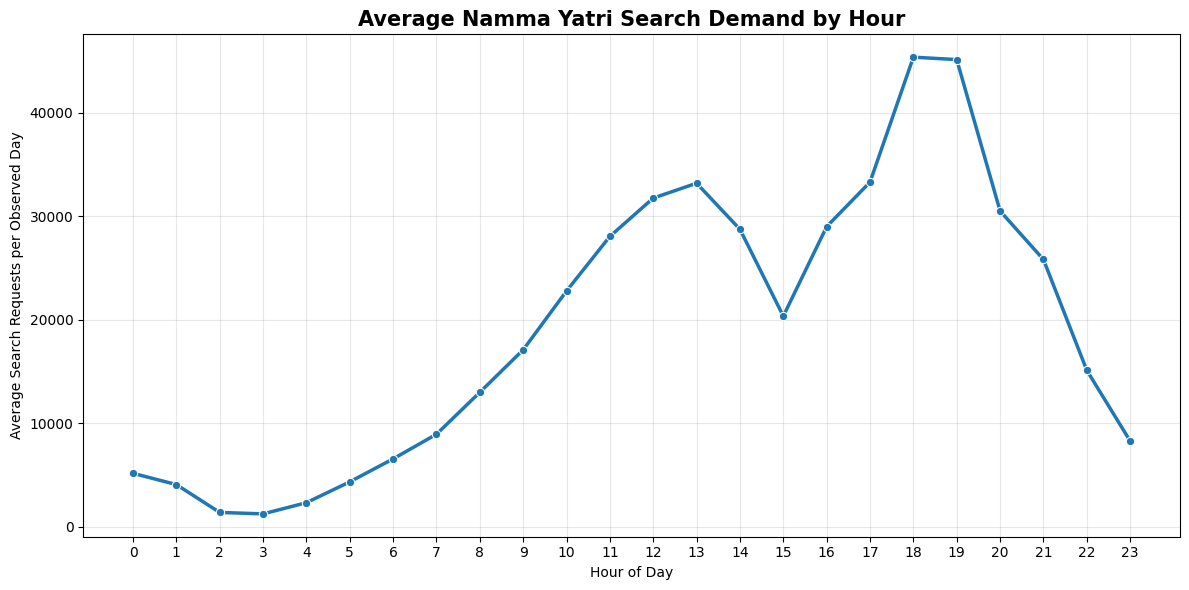

In [19]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_coverage,
    x="hour",
    y="average_searches",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Average Namma Yatri Search Demand by Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Search Requests per Observed Day")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This is important because we don't want to identify peak hours just by eyeballing the chart.

In [20]:
peak_hours = (
    hour_coverage
    .sort_values("average_searches", ascending=False)
    [["hour", "observed_days", "average_searches"]]
    .head(5)
)

low_demand_hours = (
    hour_coverage
    .sort_values("average_searches", ascending=True)
    [["hour", "observed_days", "average_searches"]]
    .head(5)
)

print("TOP 5 DEMAND HOURS")
display(peak_hours)

print("\nLOWEST 5 DEMAND HOURS")
display(low_demand_hours)

TOP 5 DEMAND HOURS


,hour,observed_days,average_searches
18,18,2,45378.500000
19,19,2,45143.500000
17,17,2,33298.000000
13,13,3,33190.666667
12,12,3,31755.333333



LOWEST 5 DEMAND HOURS


,hour,observed_days,average_searches
3,3,3,1222.000000
2,2,3,1363.666667
4,4,3,2304.000000
1,1,3,4055.333333
5,5,3,4322.333333


So the observed demand at 18:00 is roughly 37× the demand at 03:00.

One important limitation: the evening hours 16:00–23:00 are based on only 2 observed dates, while 00:00–15:00 have 3 dates. Therefore, we can describe 18:00–19:00 as the strongest evening peak in the observed sample, but we should not generalize it to all Bengaluru days yet.

### Hourly Demand Insights

The hourly demand curve reveals a strong time-of-day pattern in Namma Yatri search activity.

- Demand is lowest during the early-morning period, particularly between **02:00 and 04:00**.
- Search activity begins increasing steadily from approximately **05:00–06:00**.
- A strong daytime demand window appears around **12:00–13:00**.
- The largest observed demand peak occurs during the evening period at **18:00–19:00**.
- The highest observed hour is **18:00**, with approximately **45.4K average search requests per observed day**.
- By comparison, **03:00** records only about **1.2K average searches**, making peak observed demand roughly **37 times larger** than the lowest-demand hour.
- Demand falls rapidly again after approximately **20:00**.

### Operational Interpretation

The observed pattern suggests that driver availability and supply planning may be especially important during the evening demand window.

However, the evening hours from 16:00 onward are represented by only two observed dates, while earlier hours contain three dates. Therefore, these findings should be treated as patterns within the available sample rather than universal Bengaluru demand behaviour.

**Q. Does high demand also create a funnel problem?**

Having lots of searches at 6–7 PM is useful, but what if riders are searching and failing to progress through the E/Q stages?

In [21]:
hourly_funnel = (
    city_demand_hourly
    .groupby("hour", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        search_requests=("search_requests", "sum"),
        searches_with_e=("searches_with_e", "sum"),
        searches_for_q=("searches_for_q", "sum"),
        searches_with_q=("searches_with_q", "sum")
    )
)

hourly_funnel["e_stage_rate"] = (
    hourly_funnel["searches_with_e"]
    / hourly_funnel["search_requests"] * 100
)

hourly_funnel["q_request_rate"] = (
    hourly_funnel["searches_for_q"]
    / hourly_funnel["search_requests"] * 100
)

hourly_funnel["q_success_rate"] = (
    hourly_funnel["searches_with_q"]
    / hourly_funnel["searches_for_q"] * 100
)

hourly_funnel[
    [
        "hour",
        "observed_days",
        "search_requests",
        "e_stage_rate",
        "q_request_rate",
        "q_success_rate"
    ]
].round(2)

,hour,observed_days,search_requests,e_stage_rate,q_request_rate,q_success_rate
0,0,3,15434,99.60,73.44,66.00
1,1,3,12166,99.55,79.40,54.24
2,2,3,4091,99.56,67.64,79.29
3,3,3,3666,99.10,64.43,75.06
4,4,3,6912,99.64,60.21,67.47
5,5,3,12967,99.67,69.30,52.15
6,6,3,19626,99.72,68.23,58.66
7,7,3,26776,99.69,66.26,67.34
8,8,3,38941,99.65,68.43,67.35
9,9,3,51261,99.17,67.83,67.08


**Demand peak -> Q stage success**

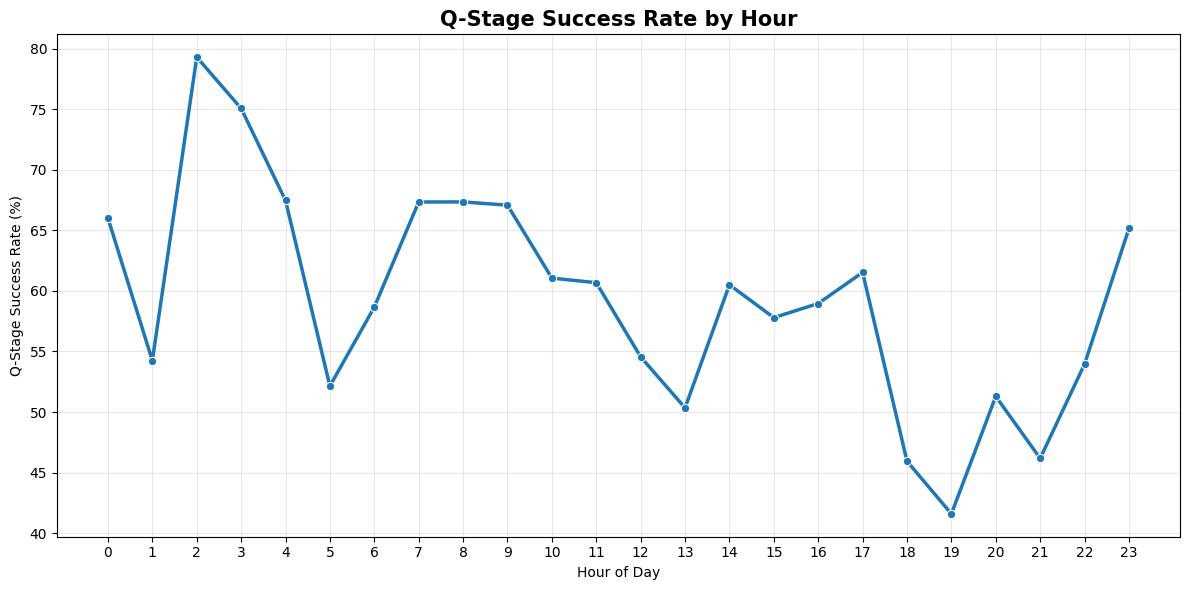

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_funnel,
    x="hour",
    y="q_success_rate",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Q-Stage Success Rate by Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Q-Stage Success Rate (%)")

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Evening demand surges

        ↓

Search system still works
(E-stage remains ~99%)

        ↓

Q-stage availability falls

        ↓
        
More riders may struggle to progress
toward a successful booking.

But we should phrase this carefully: this shows an association in our observed sample, not proof that high demand causes the Q-stage decline. Also, 18:00–23:00 contains only two observed dates.

### Demand vs Q-Stage Performance Insight

The hourly funnel analysis reveals an important contrast between initial search availability and later-stage service availability.

- The **E-stage rate remains consistently close to 99% throughout the day**, indicating that the initial search stage remains highly available even during periods of heavy demand.
- However, the **Q-stage success rate varies substantially by hour**.
- During the largest observed evening demand peak:
  - **18:00:** Q-stage success falls to approximately **45.95%**
  - **19:00:** Q-stage success falls further to approximately **41.60%**
- The 19:00 hour records the **lowest observed Q-stage success rate** despite being one of the highest-demand periods.
- By comparison, several low-demand early-morning hours achieve Q-stage success rates above 65–75%.

### Operational Interpretation

This pattern suggests a potential service-availability bottleneck during evening peak demand.

The system appears capable of processing initial rider searches, but a substantially smaller proportion of riders successfully progress through the Q-stage when demand reaches its evening peak.

This could indicate a mismatch between rider demand and available service capacity during peak hours and will later be investigated using booking, cancellation, ward-level funnel, and driver-supply information.

Because the evening hours are represented by only two observed dates, this result should be interpreted as an observed sample pattern rather than a universal Bengaluru behaviour.

In [23]:
demand_q_analysis = (
    hour_coverage[
        ["hour", "observed_days", "average_searches"]
    ]
    .merge(
        hourly_funnel[
            ["hour", "q_success_rate", "e_stage_rate"]
        ],
        on="hour",
        how="left"
    )
)

demand_q_analysis = demand_q_analysis.round(2)

demand_q_analysis.sort_values(
    "average_searches",
    ascending=False
).head(10)

,hour,observed_days,average_searches,q_success_rate,e_stage_rate
18,18,2,45378.50,45.95,99.54
19,19,2,45143.50,41.60,99.73
17,17,2,33298.00,61.53,99.81
13,13,3,33190.67,50.35,99.52
12,12,3,31755.33,54.56,99.69
20,20,2,30508.50,51.29,99.31
16,16,2,28995.00,58.96,99.73
14,14,3,28733.67,60.50,99.45
11,11,3,28052.00,60.68,99.50
21,21,2,25818.00,46.18,99.50


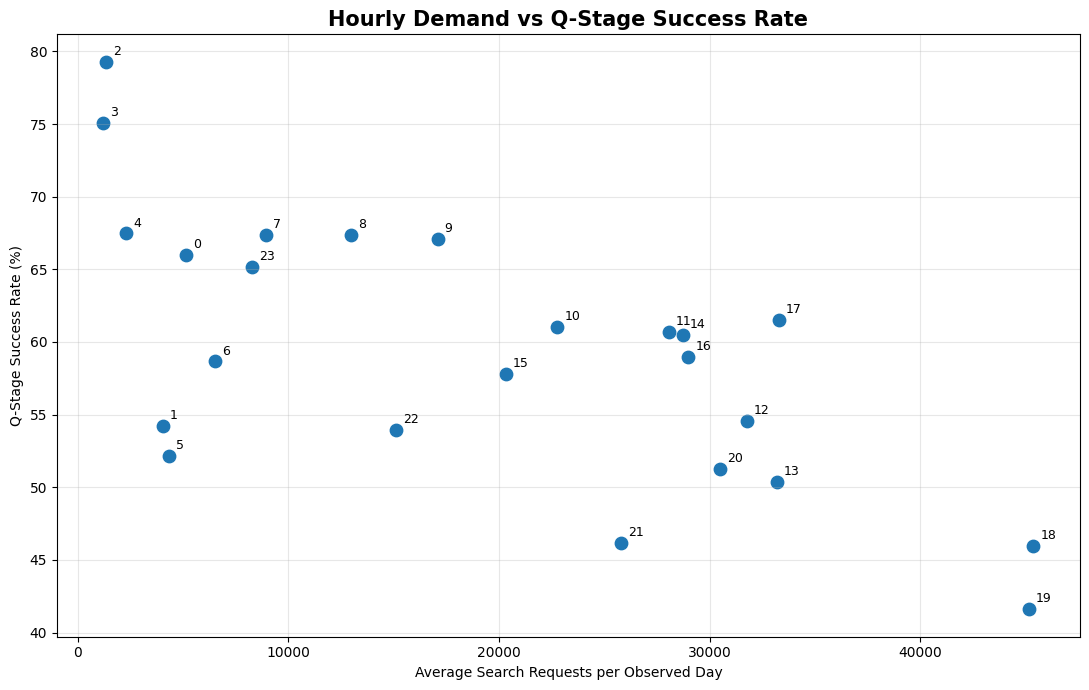

In [24]:
plt.figure(figsize=(11, 7))

plt.scatter(
    demand_q_analysis["average_searches"],
    demand_q_analysis["q_success_rate"],
    s=80
)

for _, row in demand_q_analysis.iterrows():
    plt.annotate(
        int(row["hour"]),
        (row["average_searches"], row["q_success_rate"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "Hourly Demand vs Q-Stage Success Rate",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Search Requests per Observed Day")
plt.ylabel("Q-Stage Success Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Each dot will represent **one hour**, and the number beside it is the hour.

### Demand–Q-Stage Relationship

The combined demand and Q-stage analysis highlights a possible peak-hour service-capacity issue.

- The two highest-demand hours, **18:00 and 19:00**, appear in the high-demand / low-Q-stage-success region of the scatter plot.
- **18:00** averages approximately **45.4K searches** with a Q-stage success rate of **45.95%**.
- **19:00** averages approximately **45.1K searches** while Q-stage success falls to **41.60%**, the lowest observed hourly rate.
- Several low-demand hours achieve considerably higher Q-stage success rates.

This suggests that high-demand periods may experience greater difficulty progressing riders through the Q-stage.

The relationship is observational rather than causal and is based on a limited number of observed dates.

**Q. Once riders actually book, which hours have the highest completion and cancellation problems?**

---

## 5. Hourly Booking, Completion & Cancellation Analysis

After examining search demand and Q-stage performance, the next step is to evaluate downstream operational outcomes.

The analysis focuses on:

- Booking volume
- Completed rides
- Cancelled rides
- Booking completion rate
- Booking cancellation rate
- Driver vs rider cancellations
- Earnings

As with demand analysis, hourly comparisons account for the partial third day by aggregating activity at the date-hour level before comparing hours.

**date-hour operations data**

In [25]:
city_operations["date"] = pd.to_datetime(city_operations["date"])

operations_date_hour = (
    city_operations
    .groupby(["date", "hour"], as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

print("Date-hour operational rows:", operations_date_hour.shape[0])
print("Unique dates:", operations_date_hour["date"].nunique())
print("Unique hours:", sorted(operations_date_hour["hour"].unique()))

operations_date_hour.head()

Date-hour operational rows: 64
Unique dates: 3
Unique hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,date,hour,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings
0,2026-05-03,0,2111,1894,1053,1029,398,619,273863
1,2026-05-03,1,1448,1311,643,792,324,458,187316
2,2026-05-03,2,541,504,295,238,82,154,88032
3,2026-05-03,3,456,443,247,209,69,140,78437
4,2026-05-03,4,891,878,566,322,153,169,172835


**building hourly operational KPIs**

In [26]:
hourly_operations = (
    operations_date_hour
    .groupby("hour")
    .agg(
        observed_days=("date", "nunique"),
        total_bookings=("bookings", "sum"),
        total_rides=("rides", "sum"),
        total_completed=("completed_rides", "sum"),
        total_cancelled=("cancelled_rides", "sum"),
        driver_cancels=("driver_cancels", "sum"),
        rider_cancels=("rider_cancels", "sum"),
        total_earnings=("earnings", "sum"),
        average_bookings=("bookings", "mean")
    )
    .reset_index()
)

hourly_operations["completion_rate"] = (
    hourly_operations["total_completed"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["cancellation_rate"] = (
    hourly_operations["total_cancelled"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["booking_to_ride_rate"] = (
    hourly_operations["total_rides"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations[
    [
        "hour",
        "observed_days",
        "average_bookings",
        "completion_rate",
        "cancellation_rate",
        "booking_to_ride_rate"
    ]
].round(2)

,hour,observed_days,average_bookings,completion_rate,cancellation_rate,booking_to_ride_rate
0,0,3,2072.00,52.62,46.67,94.76
1,1,3,1398.00,50.43,48.78,94.11
2,2,3,518.33,56.66,42.77,96.14
3,3,3,460.00,56.96,42.83,98.12
4,4,3,834.33,62.29,37.51,99.00
5,5,3,1456.33,66.42,33.53,99.73
6,6,3,2499.33,68.44,31.52,99.80
7,7,3,3791.33,72.59,27.40,99.65
8,8,3,5703.00,72.26,27.55,99.67
9,9,3,7430.00,71.26,27.53,99.78


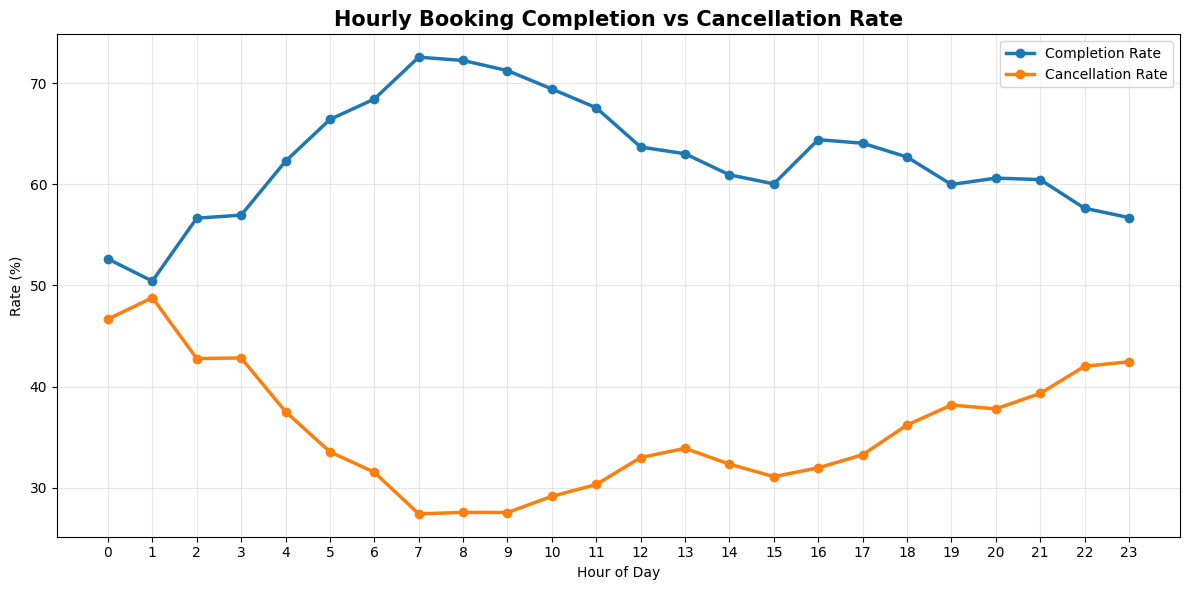

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_operations["hour"],
    hourly_operations["completion_rate"],
    marker="o",
    linewidth=2.5,
    label="Completion Rate"
)

plt.plot(
    hourly_operations["hour"],
    hourly_operations["cancellation_rate"],
    marker="o",
    linewidth=2.5,
    label="Cancellation Rate"
)

plt.title(
    "Hourly Booking Completion vs Cancellation Rate",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Rate (%)")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Hourly Operational Performance Insights

The booking-level analysis indicates that the evening demand pressure observed earlier continues into downstream ride operations.

- Booking volume increases substantially during the late afternoon and evening.
- The largest observed average booking volume occurs around **18:00**, with approximately **15.5K bookings per observed day**.
- During the morning period around **07:00–09:00**, booking completion rates exceed **71%**, while cancellation rates remain near **27%**.
- As evening demand increases, operational performance weakens:
  - **18:00:** 62.71% completion and 36.19% cancellation
  - **19:00:** 59.99% completion and 38.17% cancellation
  - **21:00:** 60.47% completion and 39.31% cancellation
- This suggests that the evening period experiences pressure not only at the Q-stage but also after riders successfully create bookings.

### Operational Interpretation

The combined funnel and booking patterns suggest a possible peak-hour capacity mismatch.

During evening demand peaks, riders are less likely to successfully progress through the Q-stage, and bookings that do occur experience lower completion and higher cancellation rates than several morning hours.

This makes the evening period an important candidate for later driver-supply and ward-level investigation.

The result remains observational and is based on a limited number of sampled dates.

One subtle point: completion rate + cancellation rate doesn't always equal 100%, because we already identified the unresolved ride-status residual. So we should not force these two lines to sum to 100%.

**Q. who is cancelling — drivers or riders?**

In [28]:
hourly_operations["driver_cancel_rate"] = (
    hourly_operations["driver_cancels"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["rider_cancel_rate"] = (
    hourly_operations["rider_cancels"]
    / hourly_operations["total_bookings"] * 100
)

hourly_operations["unclassified_cancels"] = (
    hourly_operations["total_cancelled"]
    - hourly_operations["driver_cancels"]
    - hourly_operations["rider_cancels"]
)

cancel_by_hour = hourly_operations[
    [
        "hour",
        "average_bookings",
        "cancellation_rate",
        "driver_cancel_rate",
        "rider_cancel_rate",
        "unclassified_cancels"
    ]
].round(2)

cancel_by_hour

,hour,average_bookings,cancellation_rate,driver_cancel_rate,rider_cancel_rate,unclassified_cancels
0,0,2072.00,46.67,19.22,27.24,13
1,1,1398.00,48.78,19.96,28.54,12
2,2,518.33,42.77,12.60,30.03,2
3,3,460.00,42.83,15.07,27.75,0
4,4,834.33,37.51,15.50,21.97,1
5,5,1456.33,33.53,15.11,18.31,5
6,6,2499.33,31.52,14.98,16.44,7
7,7,3791.33,27.40,13.70,13.56,16
8,8,5703.00,27.55,14.17,13.29,15
9,9,7430.00,27.53,14.01,13.46,13


This is important because the business solution differs dramatically:

- driver-heavy cancellations → supply positioning, incentives, pickup conditions

- rider-heavy cancellations → waiting time, quote experience, pricing/fare behaviour

- both rising → broader peak-hour marketplace stress

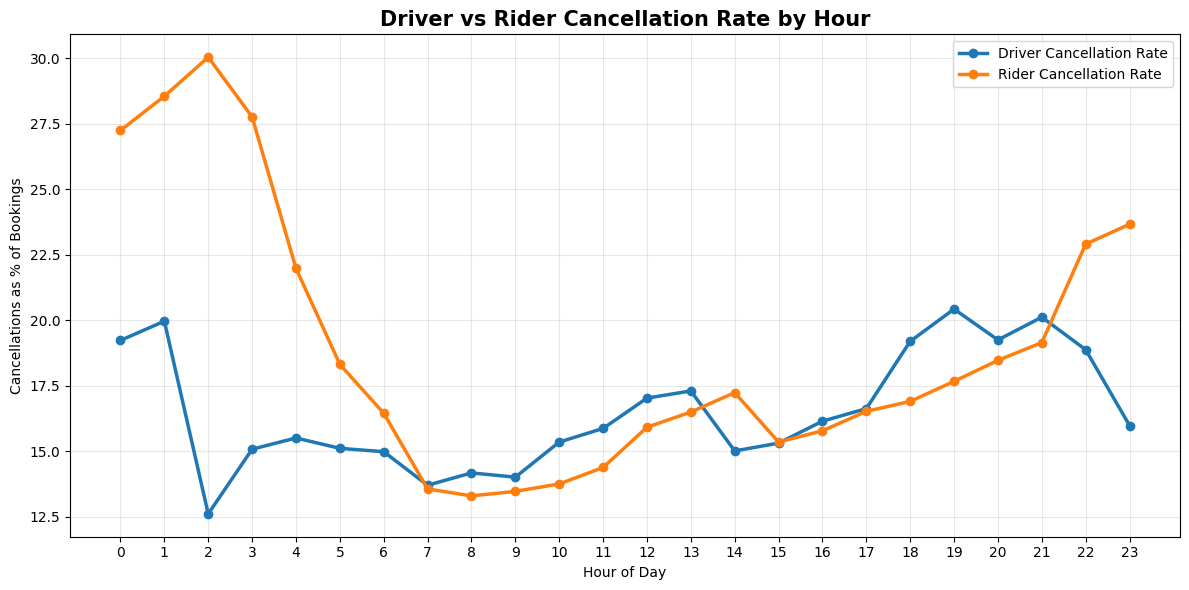

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_operations["hour"],
    hourly_operations["driver_cancel_rate"],
    marker="o",
    linewidth=2.5,
    label="Driver Cancellation Rate"
)

plt.plot(
    hourly_operations["hour"],
    hourly_operations["rider_cancel_rate"],
    marker="o",
    linewidth=2.5,
    label="Rider Cancellation Rate"
)

plt.title(
    "Driver vs Rider Cancellation Rate by Hour",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Cancellations as % of Bookings")

plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Driver vs Rider Cancellation Insights

Cancellation behaviour changes meaningfully throughout the day.

- During the morning period around **07:00–10:00**, driver and rider cancellation rates are relatively balanced and overall cancellation levels are comparatively low.
- As evening demand increases, both driver and rider cancellation rates rise.
- During the principal evening peak:
  - **18:00:** driver cancellations = 19.19%, rider cancellations = 16.90%
  - **19:00:** driver cancellations = 20.42%, rider cancellations = 17.66%
  - **21:00:** driver cancellations = 20.11%, rider cancellations = 19.14%
- The increase during the 18:00–21:00 period is therefore slightly more pronounced on the driver side.

### Late-Night Behaviour

The cancellation pattern changes again later in the night.

- At **22:00–23:00**, rider cancellations exceed driver cancellations.
- Rider cancellations are also particularly high during the early-morning hours between approximately **00:00 and 03:00**.

### Operational Interpretation

The observed evening deterioration appears to involve both sides of the marketplace, but driver cancellations contribute more strongly during the principal peak-demand period.

This supports the hypothesis that evening demand may place pressure on available driver capacity or driver willingness to fulfil bookings.

Late-night cancellations appear more rider-driven, suggesting that different operational interventions may be required for peak evening periods versus overnight periods.

These interpretations remain observational and do not establish the exact cause of cancellation behaviour.

**correlation between demand and service performance**

In [30]:
hourly_combined = (
    demand_q_analysis
    .merge(
        hourly_operations[
            [
                "hour",
                "completion_rate",
                "cancellation_rate",
                "driver_cancel_rate",
                "rider_cancel_rate"
            ]
        ],
        on="hour",
        how="left"
    )
)

hourly_combined.head()

,hour,observed_days,average_searches,q_success_rate,e_stage_rate,completion_rate,cancellation_rate,driver_cancel_rate,rider_cancel_rate
0,0,3,5144.67,66.00,99.60,52.622265,46.669884,19.224582,27.236165
1,1,3,4055.33,54.24,99.55,50.429185,48.783977,19.957082,28.540773
2,2,3,1363.67,79.29,99.56,56.655949,42.765273,12.604502,30.032154
3,3,3,1222.00,75.06,99.10,56.956522,42.826087,15.072464,27.753623
4,4,3,2304.00,67.47,99.64,62.285258,37.514982,15.501398,21.973632


In [31]:
relationship_metrics = hourly_combined[
    [
        "average_searches",
        "q_success_rate",
        "completion_rate",
        "cancellation_rate",
        "driver_cancel_rate",
        "rider_cancel_rate"
    ]
]

relationship_metrics.corr().round(3)

,average_searches,q_success_rate,completion_rate,cancellation_rate,driver_cancel_rate,rider_cancel_rate
average_searches,1.000,-0.682,0.170,-0.315,0.452,-0.553
q_success_rate,-0.682,1.000,0.060,-0.001,-0.758,0.318
completion_rate,0.170,0.060,1.000,-0.935,-0.528,-0.854
cancellation_rate,-0.315,-0.001,-0.935,1.000,0.530,0.931
driver_cancel_rate,0.452,-0.758,-0.528,0.530,1.000,0.197
rider_cancel_rate,-0.553,0.318,-0.854,0.931,0.197,1.000


This correlation will be based on only 24 hourly observations, so we're using it as exploratory evidence, not statistical proof of causality.

### Hourly Relationship Analysis

The correlation analysis provides additional evidence about how demand and operational performance vary across hours.

#### Key Observations

- **Average search demand and Q-stage success have a correlation of -0.682.**
  - Higher-demand hours tend to be associated with lower Q-stage success in the observed sample.
  - This supports the earlier finding that the evening demand peak coincides with weaker Q-stage performance.

- **Demand and driver cancellation rate have a moderate positive correlation of 0.452.**
  - Higher-demand periods tend to show somewhat greater driver-side cancellation pressure.

- **Demand and rider cancellation rate have a negative correlation of -0.553.**
  - Rider cancellations are comparatively more prominent during several lower-demand periods, particularly overnight.

- **Demand and overall cancellation rate show only a modest negative correlation (-0.315).**
  - Therefore, high demand should not be interpreted as automatically producing higher total cancellation rates.

- **Q-stage success and driver cancellation rate have a strong negative correlation (-0.758).**
  - Hours with weaker Q-stage success also tend to experience greater driver-side cancellation pressure.

### Interpretation

The hourly marketplace appears to experience different operational problems at different times.

During high-demand evening periods, Q-stage performance weakens and driver-side cancellations become more prominent.

During low-demand overnight periods, rider-side cancellations account for a larger share of booking failures.

These relationships are exploratory associations based on only 24 hourly observations and should not be interpreted as causal effects.

Correlations involving mathematically related metrics, such as total cancellations and rider/driver cancellation components, are interpreted cautiously because part of the relationship is structurally built into the metric definitions.

**Statistical check for time-based EDA**

**Spearman correlation** measures whether two variables tend to move in the same or opposite direction based on their ranking, rather than requiring a perfectly straight-line relationship.

In [32]:
spearman_corr = relationship_metrics.corr(method="spearman").round(3)

spearman_corr

,average_searches,q_success_rate,completion_rate,cancellation_rate,driver_cancel_rate,rider_cancel_rate
average_searches,1.000,-0.615,0.252,-0.295,0.463,-0.433
q_success_rate,-0.615,1.000,0.112,-0.140,-0.708,-0.025
completion_rate,0.252,0.112,1.000,-0.910,-0.473,-0.880
cancellation_rate,-0.295,-0.140,-0.910,1.000,0.540,0.962
driver_cancel_rate,0.463,-0.708,-0.473,0.540,1.000,0.364
rider_cancel_rate,-0.433,-0.025,-0.880,0.962,0.364,1.000


### Spearman Correlation Check

A Spearman rank-correlation analysis was performed as an additional robustness check because hourly marketplace behaviour is not perfectly linear.

The results support the main Pearson-correlation findings:

- Search demand vs Q-stage success: **-0.615**
- Search demand vs driver cancellation rate: **+0.463**
- Search demand vs rider cancellation rate: **-0.433**
- Q-stage success vs driver cancellation rate: **-0.708**

The direction and approximate strength of these relationships remain similar under both Pearson and Spearman correlation.

This strengthens the exploratory evidence that high-demand periods are associated with weaker Q-stage performance and increased driver-side cancellation pressure.

However, the analysis is based on only 24 hourly observations and should therefore be treated as exploratory rather than causal.

---

## 6. Vehicle Type & Trip Category Analysis

The next stage examines how operational performance differs across vehicle types and trip categories.

The analysis will compare:

- Booking volume
- Completed rides
- Cancellation volume and rate
- Driver vs rider cancellations
- Earnings
- Earnings per completed ride

Before aggregation, the available categorical values are inspected to ensure that summary categories are not accidentally double counted.

In [33]:
print("Vehicle Types:")
print(city_operations["vehicle_type"].value_counts(dropna=False))

print("\nTrip Categories:")
print(city_operations["trip_category"].value_counts(dropna=False))

print("\nBooking Types:")
print(city_operations["booking_type"].value_counts(dropna=False))

Vehicle Types:
vehicle_type
Cab     306
Auto    199
Name: count, dtype: int64

Trip Categories:
trip_category
OneWay       255
Rental       147
InterCity    103
Name: count, dtype: int64

Booking Types:
booking_type
Normal    319
Purple    186
Name: count, dtype: int64


In [34]:
category_combinations = (
    city_operations[
        ["vehicle_type", "trip_category", "booking_type"]
    ]
    .drop_duplicates()
    .sort_values(
        ["vehicle_type", "trip_category", "booking_type"]
    )
    .reset_index(drop=True)
)

category_combinations

,vehicle_type,trip_category,booking_type
0,Auto,OneWay,Normal
1,Auto,OneWay,Purple
2,Auto,Rental,Normal
3,Auto,Rental,Purple
4,Cab,InterCity,Normal
5,Cab,InterCity,Purple
6,Cab,OneWay,Normal
7,Cab,OneWay,Purple
8,Cab,Rental,Normal
9,Cab,Rental,Purple


### Operational Category Structure

The processed operational dataset contains two vehicle categories:

- `Auto`
- `Cab`

Three trip categories are available:

- `OneWay`
- `Rental`
- `InterCity`

`InterCity` activity is available only for Cab, while both Auto and Cab contain OneWay and Rental activity.

Two booking-type labels are present:

- `Normal`
- `Purple`

The meaning of `Purple` is retained as a source-system category and is not interpreted further without an official definition.

Importantly, the operational dataset contains no `"All"` vehicle summary rows. Therefore, Auto and Cab operational activity can be aggregated directly without introducing the double counting identified and prevented during Phase 1.

**Vehicle type performance**

In [35]:
vehicle_summary = (
    city_operations
    .groupby("vehicle_type", as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

vehicle_summary["completion_rate"] = (
    vehicle_summary["completed_rides"]
    / vehicle_summary["bookings"] * 100
)

vehicle_summary["cancellation_rate"] = (
    vehicle_summary["cancelled_rides"]
    / vehicle_summary["bookings"] * 100
)

vehicle_summary["earnings_per_completed_ride"] = (
    vehicle_summary["earnings"]
    / vehicle_summary["completed_rides"]
)

vehicle_summary.round(2)

,vehicle_type,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,Auto,356278,356204,236980,110233,57839,52172,34826177,66.52,30.94,146.96
1,Cab,86308,83907,45562,38408,16431,21575,18668076,52.79,44.50,409.73


In [36]:
#Verifying that nothing was lost

print("Vehicle summary bookings :", vehicle_summary["bookings"].sum())
print("Baseline bookings        :", total_bookings)

print("\nVehicle summary completed:", vehicle_summary["completed_rides"].sum())
print("Baseline completed       :", completed_rides)

print("\nVehicle summary cancels  :", vehicle_summary["cancelled_rides"].sum())
print("Baseline cancels         :", cancelled_rides)

print("\nVehicle summary earnings :", vehicle_summary["earnings"].sum())
print("Baseline earnings        :", total_earnings)

Vehicle summary bookings : 442586
Baseline bookings        : 442586

Vehicle summary completed: 282542
Baseline completed       : 282542

Vehicle summary cancels  : 148641
Baseline cancels         : 148641

Vehicle summary earnings : 53494253
Baseline earnings        : 53494253


**Vehicle comparison chart**

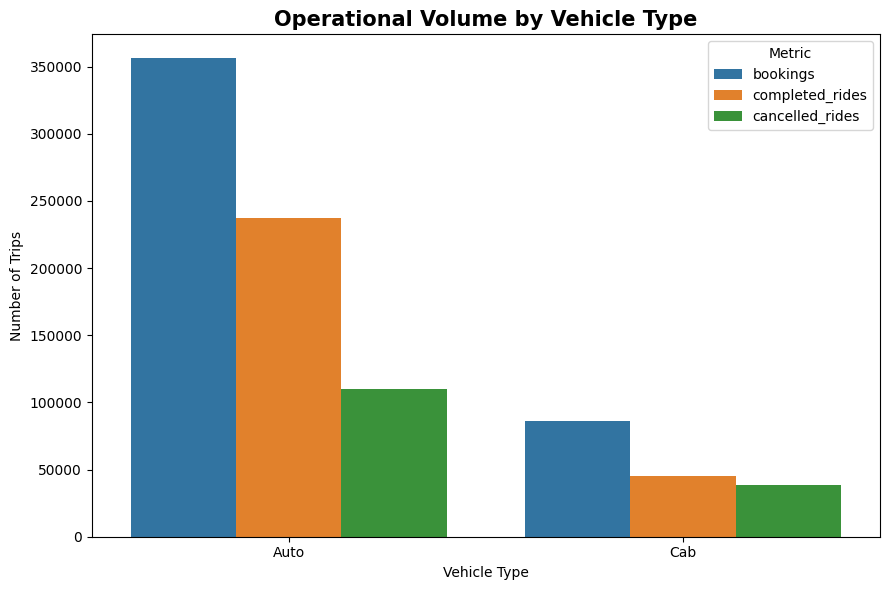

In [37]:
plt.figure(figsize=(9, 6))

vehicle_plot = vehicle_summary.melt(
    id_vars="vehicle_type",
    value_vars=["bookings", "completed_rides", "cancelled_rides"],
    var_name="Metric",
    value_name="Count"
)

sns.barplot(
    data=vehicle_plot,
    x="vehicle_type",
    y="Count",
    hue="Metric"
)

plt.title(
    "Operational Volume by Vehicle Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Trips")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Vehicle-Type Performance Insights

Vehicle-level analysis shows substantial differences between Auto and Cab operations.

- **Auto dominates operational volume**, contributing the majority of bookings and completed rides.
- Auto records **356,278 bookings**, compared with **86,308 Cab bookings**.
- Auto also demonstrates stronger fulfilment:
  - Auto completion rate: **66.52%**
  - Cab completion rate: **52.79%**
- Cab experiences considerably greater cancellation pressure:
  - Auto cancellation rate: **30.94%**
  - Cab cancellation rate: **44.50%**
- Auto generates greater total earnings because of its much larger ride volume.
- However, earnings per completed ride are substantially higher for Cab:
  - Auto: approximately **₹146.96**
  - Cab: approximately **₹409.73**

### Interpretation

Auto appears to be the dominant high-volume mobility product in the observed data, with stronger completion and lower cancellation rates.

Cab generates significantly higher earnings per completed ride, but this should not be interpreted as a pure vehicle-type effect because Cab also contains InterCity activity and may have a different trip-distance and trip-category mix.

The next analysis therefore separates performance by trip category before drawing stronger conclusions about vehicle-level economics.

**Trip category analysis**

In [38]:
trip_summary = (
    city_operations
    .groupby("trip_category", as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

trip_summary["completion_rate"] = (
    trip_summary["completed_rides"]
    / trip_summary["bookings"] * 100
)

trip_summary["cancellation_rate"] = (
    trip_summary["cancelled_rides"]
    / trip_summary["bookings"] * 100
)

trip_summary["earnings_per_completed_ride"] = (
    trip_summary["earnings"]
    / trip_summary["completed_rides"]
)

trip_summary.round(2)

,trip_category,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,InterCity,1033,854,169,839,291,458,305789,16.36,81.22,1809.40
1,OneWay,440554,438424,282132,147096,73620,73040,52952562,64.04,33.39,187.69
2,Rental,999,833,241,706,359,249,235902,24.12,70.67,978.85


In [39]:
#Verifying total gains

print("Trip summary bookings :", trip_summary["bookings"].sum())
print("Baseline bookings     :", total_bookings)

print("\nTrip summary completed:", trip_summary["completed_rides"].sum())
print("Baseline completed    :", completed_rides)

print("\nTrip summary cancels  :", trip_summary["cancelled_rides"].sum())
print("Baseline cancels      :", cancelled_rides)

print("\nTrip summary earnings :", trip_summary["earnings"].sum())
print("Baseline earnings     :", total_earnings)

Trip summary bookings : 442586
Baseline bookings     : 442586

Trip summary completed: 282542
Baseline completed    : 282542

Trip summary cancels  : 148641
Baseline cancels      : 148641

Trip summary earnings : 53494253
Baseline earnings     : 53494253


**Vehicle x Trip summary**

In [40]:
vehicle_trip_summary = (
    city_operations
    .groupby(["vehicle_type", "trip_category"], as_index=False)
    .agg(
        bookings=("booking", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        earnings=("earning", "sum")
    )
)

vehicle_trip_summary["completion_rate"] = (
    vehicle_trip_summary["completed_rides"]
    / vehicle_trip_summary["bookings"] * 100
)

vehicle_trip_summary["cancellation_rate"] = (
    vehicle_trip_summary["cancelled_rides"]
    / vehicle_trip_summary["bookings"] * 100
)

vehicle_trip_summary["earnings_per_completed_ride"] = (
    vehicle_trip_summary["earnings"]
    / vehicle_trip_summary["completed_rides"]
)

vehicle_trip_summary.round(2)

,vehicle_type,trip_category,bookings,completed_rides,cancelled_rides,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,Auto,OneWay,356043,236907,110086,34796358,66.54,30.92,146.88
1,Auto,Rental,235,73,147,29819,31.06,62.55,408.48
2,Cab,InterCity,1033,169,839,305789,16.36,81.22,1809.40
3,Cab,OneWay,84511,45225,37010,18156204,53.51,43.79,401.46
4,Cab,Rental,764,168,559,206083,21.99,73.17,1226.68


### Trip-Category and Vehicle–Trip Insights

Trip-category analysis shows that operational activity is overwhelmingly concentrated in `OneWay` trips.

- `OneWay` contributes approximately **99.54% of all bookings** in the observed operational dataset.
- Rental and InterCity bookings represent only a very small share of total volume.

### OneWay Performance

OneWay is the core operational category:

- Completion rate: **64.04%**
- Cancellation rate: **33.39%**
- Earnings per completed ride: approximately **₹187.69**

### Rental and InterCity Performance

Rental and InterCity trips show substantially higher cancellation rates:

- Rental cancellation rate: **70.67%**
- InterCity cancellation rate: **81.22%**

However, both categories have very small booking volumes, so their rates should be interpreted cautiously.

These categories also generate much higher earnings per completed ride, consistent with their different trip characteristics and likely longer-distance or longer-duration usage.

### Vehicle × Trip Category

Separating vehicle type from trip category provides a clearer comparison.

For OneWay trips:

- Auto completion rate: **66.54%**
- Cab completion rate: **53.51%**
- Auto cancellation rate: **30.92%**
- Cab cancellation rate: **43.79%**

Cab OneWay trips therefore experience weaker fulfilment than Auto OneWay trips even after controlling for trip category at this descriptive level.

Cab also generates substantially higher earnings per completed OneWay ride.

### Interpretation

The earlier difference between Auto and Cab is not explained solely by InterCity and Rental activity.

Even within the dominant OneWay category, Cab shows higher earnings per completed ride but also lower completion and higher cancellation rates.

Rental and InterCity appear economically higher-value per successful trip, but their very small observed sample sizes and high cancellation rates require cautious interpretation.

**Trip category visualization**

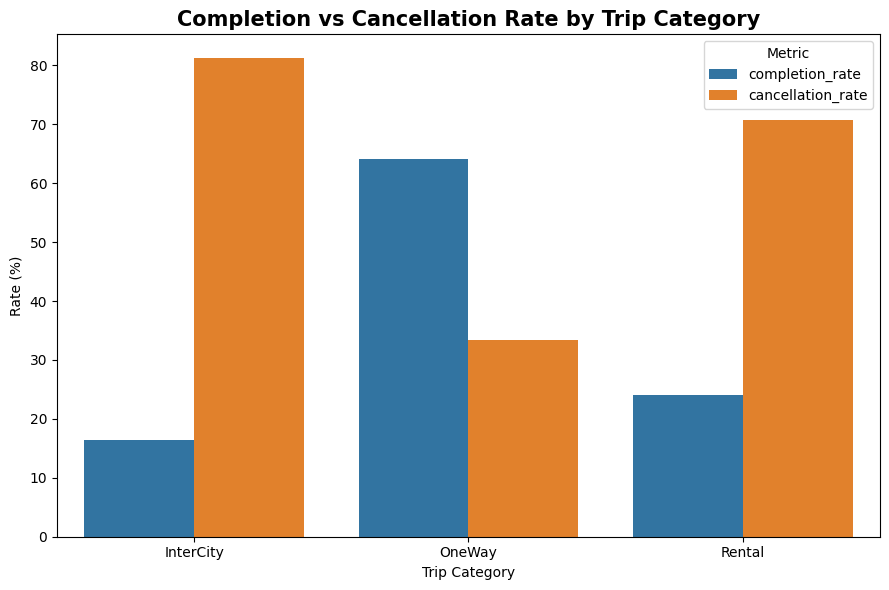

In [41]:
plt.figure(figsize=(9, 6))

trip_rate_plot = trip_summary.melt(
    id_vars="trip_category",
    value_vars=["completion_rate", "cancellation_rate"],
    var_name="Metric",
    value_name="Rate"
)

sns.barplot(
    data=trip_rate_plot,
    x="trip_category",
    y="Rate",
    hue="Metric"
)

plt.title(
    "Completion vs Cancellation Rate by Trip Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Trip Category")
plt.ylabel("Rate (%)")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Booking-Type Analysis

The operational dataset contains two booking-type labels:

- `Normal`
- `Purple`

Because the source data does not provide a confirmed business definition for `Purple`, the label is retained as-is.

The analysis compares the two booking types descriptively using:

- Booking volume
- Completed rides
- Cancellation rate
- Driver and rider cancellations
- Earnings
- Earnings per completed ride

**Booking type summary**

In [42]:
booking_type_summary = (
    city_operations
    .groupby("booking_type", as_index=False)
    .agg(
        bookings=("booking", "sum"),
        rides=("rides", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum"),
        driver_cancels=("drvr_cancel", "sum"),
        rider_cancels=("rider_cancel", "sum"),
        earnings=("earning", "sum")
    )
)

booking_type_summary["completion_rate"] = (
    booking_type_summary["completed_rides"]
    / booking_type_summary["bookings"] * 100
)

booking_type_summary["cancellation_rate"] = (
    booking_type_summary["cancelled_rides"]
    / booking_type_summary["bookings"] * 100
)

booking_type_summary["earnings_per_completed_ride"] = (
    booking_type_summary["earnings"]
    / booking_type_summary["completed_rides"]
)

booking_type_summary.round(2)

,booking_type,bookings,rides,completed_rides,cancelled_rides,driver_cancels,rider_cancels,earnings,completion_rate,cancellation_rate,earnings_per_completed_ride
0,Normal,439548,437111,280882,147335,73590,73127,53187423,63.90,33.52,189.36
1,Purple,3038,3000,1660,1306,680,620,306830,54.64,42.99,184.84


In [43]:
print("Booking-type bookings :", booking_type_summary["bookings"].sum())
print("Baseline bookings     :", total_bookings)

print("\nBooking-type completed:", booking_type_summary["completed_rides"].sum())
print("Baseline completed    :", completed_rides)

print("\nBooking-type cancels  :", booking_type_summary["cancelled_rides"].sum())
print("Baseline cancels      :", cancelled_rides)

print("\nBooking-type earnings :", booking_type_summary["earnings"].sum())
print("Baseline earnings     :", total_earnings)

Booking-type bookings : 442586
Baseline bookings     : 442586

Booking-type completed: 282542
Baseline completed    : 282542

Booking-type cancels  : 148641
Baseline cancels      : 148641

Booking-type earnings : 53494253
Baseline earnings     : 53494253


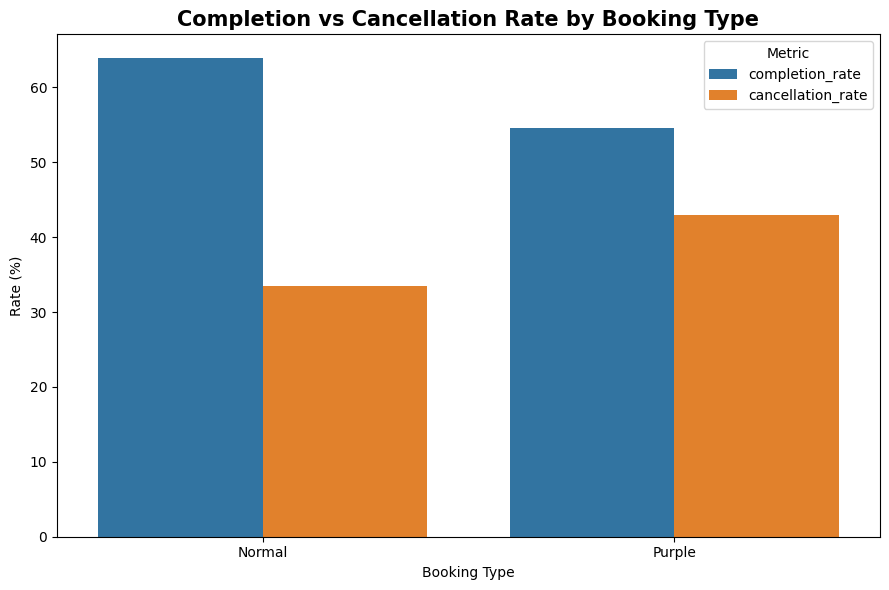

In [44]:
plt.figure(figsize=(9, 6))

booking_type_plot = booking_type_summary.melt(
    id_vars="booking_type",
    value_vars=["completion_rate", "cancellation_rate"],
    var_name="Metric",
    value_name="Rate"
)

sns.barplot(
    data=booking_type_plot,
    x="booking_type",
    y="Rate",
    hue="Metric"
)

plt.title(
    "Completion vs Cancellation Rate by Booking Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Booking Type")
plt.ylabel("Rate (%)")
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Booking-Type Insights

Booking activity is overwhelmingly concentrated in the `Normal` booking type.

- `Normal` accounts for approximately **99.3% of all bookings**.
- `Purple` contributes only about **0.7% of total booking volume**.

Operationally:

- Normal completion rate: **63.90%**
- Purple completion rate: **54.64%**
- Normal cancellation rate: **33.52%**
- Purple cancellation rate: **42.99%**

Purple therefore shows weaker fulfilment within the observed sample.

However, because Purple represents a very small share of total activity and its exact business definition is not confirmed, the difference should be interpreted cautiously.

Earnings per completed ride are very similar between the two booking types, suggesting that the primary observed difference is related to fulfilment rather than earnings per successful ride.

**Final composition check**

In [45]:
booking_mix = (
    city_operations
    .groupby(
        ["booking_type", "vehicle_type", "trip_category"],
        as_index=False
    )
    .agg(
        bookings=("booking", "sum"),
        completed_rides=("done_ride", "sum"),
        cancelled_rides=("cancel_ride", "sum")
    )
)

booking_mix["completion_rate"] = (
    booking_mix["completed_rides"]
    / booking_mix["bookings"] * 100
)

booking_mix["cancellation_rate"] = (
    booking_mix["cancelled_rides"]
    / booking_mix["bookings"] * 100
)

booking_mix.round(2)

,booking_type,vehicle_type,trip_category,bookings,completed_rides,cancelled_rides,completion_rate,cancellation_rate
0,Normal,Auto,OneWay,353624,235481,109152,66.59,30.87
1,Normal,Auto,Rental,235,73,147,31.06,62.55
2,Normal,Cab,InterCity,994,168,801,16.90,80.58
3,Normal,Cab,OneWay,83937,44993,36681,53.60,43.70
4,Normal,Cab,Rental,758,167,554,22.03,73.09
5,Purple,Auto,OneWay,2419,1426,934,58.95,38.61
6,Purple,Auto,Rental,0,0,0,NaN,NaN
7,Purple,Cab,InterCity,39,1,38,2.56,97.44
8,Purple,Cab,OneWay,574,232,329,40.42,57.32
9,Purple,Cab,Rental,6,1,5,16.67,83.33


In [46]:
booking_mix_share = (
    booking_mix
    .copy()
)

booking_mix_share["booking_type_total"] = (
    booking_mix_share
    .groupby("booking_type")["bookings"]
    .transform("sum")
)

booking_mix_share["within_type_share_%"] = (
    booking_mix_share["bookings"]
    / booking_mix_share["booking_type_total"] * 100
)

booking_mix_share[
    [
        "booking_type",
        "vehicle_type",
        "trip_category",
        "bookings",
        "within_type_share_%",
        "completion_rate",
        "cancellation_rate"
    ]
].round(2)

,booking_type,vehicle_type,trip_category,bookings,within_type_share_%,completion_rate,cancellation_rate
0,Normal,Auto,OneWay,353624,80.45,66.59,30.87
1,Normal,Auto,Rental,235,0.05,31.06,62.55
2,Normal,Cab,InterCity,994,0.23,16.90,80.58
3,Normal,Cab,OneWay,83937,19.10,53.60,43.70
4,Normal,Cab,Rental,758,0.17,22.03,73.09
5,Purple,Auto,OneWay,2419,79.62,58.95,38.61
6,Purple,Auto,Rental,0,0.00,NaN,NaN
7,Purple,Cab,InterCity,39,1.28,2.56,97.44
8,Purple,Cab,OneWay,574,18.89,40.42,57.32
9,Purple,Cab,Rental,6,0.20,16.67,83.33


### Booking-Type Composition Check

The weaker performance observed for the `Purple` booking type is not explained solely by differences in vehicle or trip-category composition.

Both booking types have a very similar operational mix:

- Approximately 80% of activity comes from Auto OneWay trips.
- Approximately 19% comes from Cab OneWay trips.
- Rental and InterCity activity represent only a very small share.

Performance differences remain visible even within the same dominant segments.

For Auto OneWay trips:

- Normal completion rate: 66.59%
- Purple completion rate: 58.95%
- Normal cancellation rate: 30.87%
- Purple cancellation rate: 38.61%

For Cab OneWay trips:

- Normal completion rate: 53.60%
- Purple completion rate: 40.42%
- Normal cancellation rate: 43.70%
- Purple cancellation rate: 57.32%

This indicates that the observed Purple-vs-Normal fulfilment gap is not purely a result of different vehicle/trip mixes.

However, because the exact business meaning of `Purple` is not confirmed and Purple represents a very small portion of total bookings, no causal interpretation is made.

---

## 7. Ward-Level Funnel & Geographic Demand Analysis

City-level analysis identifies when operational pressure occurs, but it does not reveal where that pressure is concentrated.

The ward-level funnel dataset is therefore used to identify geographic differences in:

- Search demand
- Q-stage progression
- Bookings
- Completed rides
- Cancellations
- Conversion behaviour
- Vehicle and trip-category activity

This analysis will later be combined with driver-supply information to identify potential demand–supply mismatch zones across Bengaluru.